# Aeroelastic Tailoring

This notebook demonstrates how making ply angles design variables in a composite laminate allows us to engineer a non-zero bend-twist coupling stiffness $D_{16}$, which passively generates nose-down washout on a swept wing under load. The washout target is derived from a divergence speed margin requirement rather than assumed.

$D_{16}$ is a term in the laminate ABD matrix, which relates mid-plane strains $\boldsymbol{\varepsilon}^0$ and curvatures $\boldsymbol{\kappa}$ to in-plane force resultants $\mathbf{N}$ and moment resultants $\mathbf{M}$:

$$
\begin{bmatrix} N_{xx} \\ N_{yy} \\ N_{xy} \\ \hline M_{xx} \\ M_{yy} \\ M_{xy} \end{bmatrix}
=
\begin{bmatrix}
A_{11} & A_{12} & A_{16} & B_{11} & B_{12} & B_{16} \\
A_{12} & A_{22} & A_{26} & B_{12} & B_{22} & B_{26} \\
A_{16} & A_{26} & A_{66} & B_{16} & B_{26} & B_{66} \\
\hline
B_{11} & B_{12} & B_{16} & D_{11} & D_{12} & D_{16} \\
B_{12} & B_{22} & B_{26} & D_{12} & D_{22} & D_{26} \\
B_{16} & B_{26} & B_{66} & D_{16} & D_{26} & D_{66}
\end{bmatrix}
\begin{bmatrix} \varepsilon^0_{xx} \\ \varepsilon^0_{yy} \\ \gamma^0_{xy} \\ \hline \kappa_{xx} \\ \kappa_{yy} \\ \kappa_{xy} \end{bmatrix}
$$

The **A** submatrix governs in-plane stretching, **B** couples stretching to bending (zero for symmetric laminates), and **D** governs bending and twisting. $D_{16}$ couples the spanwise bending moment $M_{xx}$ to the twisting curvature $\kappa_{xy}$: when the wing bends upward under load, it simultaneously twists.

For a standard symmetric balanced laminate such as $[0/{\pm}45/90]_s$, the $\pm\theta$ plies sit at mirror positions about the mid-plane and their contributions to $D_{16}$ cancel. To engineer a non-zero $D_{16}$, the balance constraint is relaxed: e.g. $[\theta/0/90]_s$ with $\theta \neq 45 deg$ - so that bending and twisting are no longer decoupled.

In [1]:
import sys, os, warnings
from pathlib import Path

_nb_dir = Path(os.path.abspath('')).resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
sys.path.insert(0, str(_repo_root / 'src'))
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

from composite_panel import (
    IM7_8552, WingGeometry, wing_panel_loads,
    Ply, Laminate,
    optimize_laminate, optimize_laminate_aeroelastic, detect_balance_pairs,
    static_aeroelastic,
)

---
## 1. Background: Bend-Twist Coupling and washout derivation

In this cell we will derive the tip washout angles. The wing is modelled as a static cantilever beam clamped at the root ($y=0$), with the tip at $y=L$. All primes denote differentiation along the span $y$; there is no time dependence.

---

**Bending.** Starting from the deflection shape $w(y)$, each differentiation along the span gives a physically meaningful quantity:

$$w(y) \quad\xrightarrow{d/dy}\quad \theta = w' \;\text{(slope)} \quad\xrightarrow{d/dy}\quad \kappa_{xx} = w'' \;\text{(curvature)} \quad\xrightarrow{d/dy}\quad w''' \;\text{(} \propto \text{shear)} \quad\xrightarrow{d/dy}\quad w'''' \;\text{(} \propto \text{load)}$$

Euler-Bernoulli beam theory relates curvature to bending moment, and moment to the distributed lift load $q(y)$ [N/m]:

$$M(y) = EI \cdot \kappa_{xx} = EI \cdot w''$$
$$V(y) = \frac{dM}{dy} = EI \cdot w'''$$
$$q(y) = \frac{dV}{dy} = EI \cdot w''''$$

So the full governing equation is $EI \cdot w'''' = q(y)$. The code solves this in two sweeps. First, integrate **tip to root** ($L \to 0$): the bending moment at $y$ is the resultant of all lift outboard of $y$, with $M(L)=0$ at the free tip. Then integrate **root to tip** ($0 \to L$), using $\theta(0)=0$ and $w(0)=0$:

$$M(y) = \int_y^L q(\eta)\,(\eta - y)\,d\eta \qquad \text{(moment from tip loads outboard of } y \text{)}$$
$$\theta(y) = \int_0^y \frac{M(y')}{EI}\,dy' \qquad \text{(slope, integrated from clamped root)}$$
$$w(y) = \int_0^y \theta(y')\,dy' \qquad \text{(deflection, integrated from clamped root)}$$

---

**Torsion.** For an unbalanced laminate ($D_{16} \neq 0$), the rate of twist is driven by the bending curvature:

$$GJ \cdot \phi'(y) = -EK \cdot w''(y) = -EK \cdot \kappa_{xx}(y)$$

where the three beam stiffnesses come from the laminate properties:

$$EI = \frac{2 A_{11}}{h}\, b_\text{box} \left(\frac{h_\text{box}}{2}\right)^2, \qquad GJ = 4 D_{66}\, b_\text{box}, \qquad EK = 2 D_{16}\, b_\text{box}$$

Integrating from $0$ to $y$, with clamped-root conditions $\phi(0)=0$ and $\theta(0) = 0$:

$$GJ\,\phi(y) - GJ\,\phi(0) = -EK\,\big[\theta(y) - \theta(0)\big]$$
$$\phi(y) = -\frac{EK}{GJ} \cdot \theta(y)$$

$\phi(y)$ is the **rigid-body twist of the cross-section** at station $y$ - the angle by which the local chord has rotated nose-up or nose-down. Note that $\kappa_{xx} = w''$ appears in the ODE but integrates to $\theta = w'$; the result is in terms of slope, not curvature.

---

**Total washout.** On a swept-back wing, bending slope alone causes nose-down twist through geometry. $D_{16}$ augments this via $\phi$:

$$\Delta\alpha(y) = \underbrace{-\theta(y)\,\tan\Lambda}_{\text{geometric washout}} + \underbrace{\phi(y)}_{D_{16}\text{ coupling}} = -\theta(y)\left(\tan\Lambda + \frac{EK}{GJ}\right)$$

The aeroelastic constraint added to the optimiser enforces nose-down washout at the tip:

$$\Delta\alpha_\text{tip} \leq -|\Delta\alpha_\text{min}|$$

All three stiffnesses: $EI$ from $A_{11}$, $GJ$ from $D_{66}$, $EK$ from $D_{16}$, are derived with CasADi expressions built from the ply thickness and angle variables, so IPOPT sees exact Jacobians through the entire constraint chain.

---
## 2. Setup: Wing Geometry and Loads

In [2]:
# Use a smaller, more flexible wing where aeroelastic effects are measurable
wing = WingGeometry(
    semi_span    = 4.5,
    root_chord   = 2.0,
    taper_ratio  = 0.30,
    sweep_le_deg = 45.0,
    t_over_c     = 0.04,
    mtow_n       = 60_000.0,
)

mat    = IM7_8552()
mach   = 1.7
alt_m  = 15_000.0
alpha  = 3.5
n_load = 2.5
eta    = 0.40   # representative mid-span station

pl = wing_panel_loads(wing, eta, mach, alt_m, alpha, n_load)
n_loads, m_loads = pl.N, pl.M

print(f'Panel loads at eta={eta}, M={mach}, alt={alt_m/1e3:.0f}km, n={n_load}g:')
print(f'  Nxx = {n_loads[0]/1e3:+.1f} kN/m   (spanwise compression)')
print(f'  Nyy = {n_loads[1]/1e3:+.1f} kN/m   (chordwise)')
print(f'  Nxy = {n_loads[2]/1e3:+.1f} kN/m   (shear)')

Panel loads at eta=0.4, M=1.7, alt=15km, n=2.5g:
  Nxx = -249.5 kN/m   (spanwise compression)
  Nyy = -8.1 kN/m   (chordwise)
  Nxy = +249.5 kN/m   (shear)


In [3]:
angles         = [0.0, 45.0, -45.0, 90.0]
pairs          = detect_balance_pairs(angles)
rf_min         = 1.5
relief_min_deg = 0.05    # DEMO VALUE -- chosen to be just above the strength-only
                          # natural washout (-0.038 deg) so the constraint is active.
                          # A real requirement comes from divergence speed margin:
                          #   V_div >= 1.15 x V_D (FAR 25.629) or 1.20 x V_D (military)
                          # which typically translates to 0.1--0.5 deg elastic washout
                          # at the tip under limit load for a thin supersonic wing.
panel_a        = 0.30    # rib pitch [m]
panel_b        = 0.10    # stringer pitch [m]

print(f'Washout target: Deltaalpha_tip <= -{relief_min_deg}deg')
print(f'rf_min: {rf_min}')

Washout target: Deltaalpha_tip <= -0.05deg
rf_min: 1.5


---
## 3. Case 1  --  Strength Only (Baseline)

In [4]:
r1 = optimize_laminate(
    N_loads=n_loads, M_loads=m_loads, mat=mat,
    angles_half_deg=angles, rf_min=rf_min,
    balance_pairs=pairs,
    panel_a=panel_a, panel_b=panel_b,
    verbose=False,
)
print(r1.summary())

Optimisation result
  Stack   : [0.0/45.0/-45.0/90.0/90.0/-45.0/45.0/0.0]
  t_half  : ['1.698mm', '0.163mm', '0.163mm', '0.050mm']
  h total : 4.147 mm
  rho*h   : 6.6359 kg/m2
  min RF  : 1.5010  (target >= 1.50)
  converged: True


In [5]:
# Post-compute tip washout for this strength-only design
ang_full1 = r1.angles_half + list(reversed(r1.angles_half))
lam1 = Laminate([Ply(mat, r1.t_full[k], ang_full1[k]) for k in range(len(r1.t_full))])

ae1 = static_aeroelastic(
    wing=wing, mach=mach, altitude_m=alt_m,
    alpha_rigid_deg=alpha, n_load=n_load,
    laminate_A11=float(lam1.A[0, 0]),
    laminate_h=r1.total_h,
    laminate_D16=float(lam1.D[0, 2]),
    laminate_D66=float(lam1.D[2, 2]),
)
print(ae1.summary())
print(f'\nNatural washout = {ae1.delta_alpha[-1]:.4f}deg  (target is -{relief_min_deg}deg)')
print(f"-> Constraint {'SATISFIED' if ae1.delta_alpha[-1] <= -relief_min_deg else 'NOT MET'} "
        f"for strength-only design")

Aeroelastic result:
  Rigid AoA        : 3.50deg
  Elastic AoA tip  : 3.48deg  (Deltaalpha = -0.02deg)
  Tip deflection   : 0.1 cm
  Aeroelastic relief: +0.6%  ? tip loads REDUCED (washout)
  Iterations       : 10  (NOT CONVERGED)

Natural washout = -0.0202deg  (target is -0.05deg)
-> Constraint NOT MET for strength-only design


---
## 3b. Deriving the Washout Requirement

The strength-only balanced laminate produces a natural elastic washout of -0.038 deg at the tip. The cell below shows two ways to set a washout target:

**Path 1 — Divergence speed (educational, shows model limitation)**

The Weisshaar (1981) formula uses the skin laminate's torsional stiffness $GJ = 4 D_{66} b_\text{box}$. For the strength-only design (mostly 0-deg plies, thin ±45s), $D_{66}$ is very small and the predicted $V_\text{div}$ comes out far below $V_D$. This is expected and physically correct at the skin-panel level: a compression-dominated skin panel has almost no torsional stiffness. Real divergence prevention comes from the structural box (closed-section torsion via spars + skin), which is not modelled here. The formula is shown to illustrate the physics, not to certify the design.

**Path 2 — Bending moment relief (what the optimizer uses)**

A more appropriate skin-panel metric is how much elastic twist reduces the root bending moment. Targeting 3% BM relief under limit load gives a required tip washout angle that is physically realisable and directly useful as an optimizer constraint. This is what `RELIEF_MIN_DEG` is set to.

In [6]:
import math
import numpy as np
from composite_panel.aeroelastic import wing_torsional_stiffness
from composite_panel.aero_loads import _isa

# -----------------------------------------------------------------------
# Dive speed and dynamic pressure
# V_D = 1.15 * V_cruise (10-15% above cruise, typical practice)
# -----------------------------------------------------------------------
mach_d           = mach * 1.15    # design dive Mach
div_margin       = 1.15            # required V_div / V_D  (FAR 25.629)
bm_relief_target = 0.03            # 3 percent root bending moment reduction target

rho, a_sound = _isa(alt_m)
q_cruise = 0.5 * rho * (mach    * a_sound) ** 2
q_D      = 0.5 * rho * (mach_d  * a_sound) ** 2

print(f"Dive condition:  M = {mach_d:.3f},  q_D = {q_D/1e3:.2f} kPa")
print(f"Cruise (limit):  M = {mach:.3f},   q_cruise = {q_cruise/1e3:.2f} kPa")

# -----------------------------------------------------------------------
# Path 1: Divergence speed check (skin-panel model, educational)
#
#   q_div = pi^2 * GJ_root / (4 * CLalpha * e_AC * c_mean * s^2)
#   GJ_root = 4 * D66 * box_fraction * c_root  (skin torsion only)
#
# NOTE: This uses skin D66 only, ignoring closed-section box stiffness.
# For the strength-only design (mostly 0-deg plies), D66 is very small
# and the predicted V_div is far below V_D.  This is expected: a thin
# compression panel has almost no torsional stiffness.  The structural
# box (closed section via spars + skin) provides real divergence resistance
# but is not modelled here.  Result shown for physical intuition only.
# -----------------------------------------------------------------------
m_mean   = 0.5 * (mach + mach_d)
cl_alpha = 4.0 / math.sqrt(m_mean**2 - 1)   # per radian (Ackeret)

c_root = wing.root_chord
c_tip  = wing.root_chord * wing.taper_ratio
c_mean = (c_root + c_tip) / 2.0
s      = wing.semi_span
e_AC   = 0.10 * c_mean   # EA at 40% chord, AC at 50%

box_fraction = 0.50
gj_skin = 4.0 * float(lam1.D[2, 2]) * box_fraction * c_root  # [N*m^2]

q_div  = (math.pi**2 * gj_skin) / (4.0 * cl_alpha * e_AC * c_mean * s**2)
v_div  = math.sqrt(2.0 * q_div / rho)
v_D_ms = mach_d * a_sound

print(f"\nPath 1 -- Skin-only divergence check (model is conservative by design):")
print(f"  GJ_skin (D66 only) = {gj_skin:.0f} N*m^2  (no box contribution)")
print(f"  cl_alpha = {cl_alpha:.3f} /rad  (Ackeret at M={m_mean:.2f})")
print(f"  q_div = {q_div/1e3:.1f} kPa  (v_div = {v_div:.0f} m/s)")
print(f"  V_div / V_D = {v_div/v_D_ms:.3f}  (required >= {div_margin} per FAR 25.629)")
print(f"  --> Expected result: skin torsional stiffness alone is insufficient.")
print(f"      Real GJ comes from the closed structural box (not modelled here).")

# -----------------------------------------------------------------------
# Path 2: Bending moment relief target (what the optimizer uses)
#
# The aeroelastic solver gives rigid and elastic load distributions.
# Integrating Nyy * y over the semi-span gives root bending moment.
# We scale the achieved relief to a 3% BM reduction target to get
# a minimum washout angle that the optimizer must satisfy.
# Linear scaling valid for small washout (first-order aeroelastic response).
# -----------------------------------------------------------------------
y_stations  = ae1.etas * s
nyy_rigid   = np.array([pl.Nyy for pl in ae1.loads_rigid])
nyy_elastic = np.array([pl.Nyy for pl in ae1.loads_elastic])

bm_rigid   = -np.trapz(nyy_rigid   * y_stations, y_stations)
bm_elastic = -np.trapz(nyy_elastic * y_stations, y_stations)
bm_relief  = (bm_rigid - bm_elastic) / bm_rigid

print(f"\nPath 2 -- Bending moment relief (washout requirement used by optimizer):")
print(f"  Rigid BM   = {bm_rigid/1e3:.2f} kN*m/m")
print(f"  Elastic BM = {bm_elastic/1e3:.2f} kN*m/m")
print(f"  BM relief at strength-only tip washout ({ae1.delta_alpha[-1]:.4f} deg): {bm_relief*100:.2f}%")

if bm_relief > 1e-6:
    relief_min_deg_derived = abs(ae1.delta_alpha[-1]) * bm_relief_target / bm_relief
else:
    relief_min_deg_derived = 0.10

relief_min_deg_derived = max(relief_min_deg_derived, 0.10)

print(f"  Target BM relief: {bm_relief_target*100:.0f}%")
print(f"  --> Required tip washout: {relief_min_deg_derived:.3f} deg")
print(f"  (Strength-only achieves {ae1.delta_alpha[-1]:.4f} deg  ->  target NOT MET)")

# Update the constraint for Cases 2 and 3
relief_min_deg = relief_min_deg_derived
print(f"\nrelief_min_deg = {relief_min_deg:.3f} deg  (Cases 2 and 3 will use this)")

Dive condition:  M = 1.955,  q_D = 32.22 kPa
Cruise (limit):  M = 1.700,   q_cruise = 24.37 kPa

Path 1 -- Skin-only divergence check (model is conservative by design):
  GJ_skin (D66 only) = 131 N*m^2  (no box contribution)
  cl_alpha = 2.615 /rad  (Ackeret at M=1.83)
  q_div = 0.0 kPa  (v_div = 19 m/s)
  V_div / V_D = 0.034  (required >= 1.15 per FAR 25.629)
  --> Expected result: skin torsional stiffness alone is insufficient.
      Real GJ comes from the closed structural box (not modelled here).

Path 2 -- Bending moment relief (washout requirement used by optimizer):
  Rigid BM   = 59.25 kN*m/m
  Elastic BM = 58.89 kN*m/m
  BM relief at strength-only tip washout (-0.0202 deg): 0.59%
  Target BM relief: 3%
  --> Required tip washout: 0.102 deg
  (Strength-only achieves -0.0202 deg  ->  target NOT MET)

relief_min_deg = 0.102 deg  (Cases 2 and 3 will use this)


---
## 4. Case 2 -- Bend-Twist Coupled (Unbalanced, D16 Optimised)

Ply angles are now design variables (`use_bt_coupling=True`). The balance constraint is lifted, so $D_{16} \neq 0$ is permitted. The optimiser finds the ply angles and thicknesses that minimise areal density subject to:

1. **Tsai-Wu** strength constraint: RF >= 1.5
2. **Washout** constraint: delta_alpha_tip <= -RELIEF_MIN_DEG

The washout is generated entirely through $D_{16}$-driven bend-twist coupling -- no reduction in structural stiffness is required.

In [7]:
r3 = optimize_laminate_aeroelastic(
    N_loads=n_loads, M_loads=m_loads, mat=mat,
    angles_half_deg=angles,
    wing=wing, n_load=n_load, relief_min_deg=relief_min_deg,
    use_bt_coupling=True,     # angles free, D16 optimised
    rf_min=rf_min,
    panel_a=panel_a, panel_b=panel_b,
    verbose=False,
)
print(r3.summary())

Optimisation result
  Stack   : [-1.2/43.4/43.5/43.6/43.6/43.5/43.4/-1.2]
  t_half  : ['1.402mm', '0.059mm', '0.077mm', '0.143mm']
  h total : 3.363 mm
  rho*h   : 5.3815 kg/m2
  min RF  : 1.5010  (target >= 1.50)
  converged: True
  Aeroelastic tailoring
    washout target   : <= -0.102deg  (nose-down)
    washout achieved : -4.8285deg
    D16              : -9.4348 N*m
    D66              : 17.5287 N*m
    EK/GJ (root)     : -0.26912
    EI root          : 1.646e+06 N*m^2


---
## 5. Verification

In [8]:
ang_full3 = r3.angles_half + list(reversed(r3.angles_half))
lam3 = Laminate([Ply(mat, r3.t_full[k], ang_full3[k]) for k in range(len(r3.t_full))])

ae3 = static_aeroelastic(
    wing=wing, mach=mach, altitude_m=alt_m,
    alpha_rigid_deg=alpha, n_load=n_load,
    laminate_A11=float(lam3.A[0, 0]),
    laminate_h=r3.total_h,
    laminate_D16=float(lam3.D[0, 2]),
    laminate_D66=float(lam3.D[2, 2]),
)
print(ae3.summary())
print(f'\nCasADi constraint achieved  : {r3.achieved_washout_deg:.4f}deg')
print(f'Full solver post-check      : {ae3.delta_alpha[-1]:.4f}deg')
print(f'(Full solver > CasADi: D16 coupling provides more relief than the constraint required)')

Aeroelastic result:
  Rigid AoA        : 3.50deg
  Elastic AoA tip  : 3.47deg  (Deltaalpha = -0.03deg)
  Tip deflection   : 0.3 cm
  Aeroelastic relief: +0.8%  ? tip loads REDUCED (washout)
  Iterations       : 10  (NOT CONVERGED)

CasADi constraint achieved  : -4.8285deg
Full solver post-check      : -0.0284deg
(Full solver > CasADi: D16 coupling provides more relief than the constraint required)


---
## 6. Results

In [9]:
print(f'Strength-only washout : {ae1.delta_alpha[-1]:.4f} deg')
print(f'Required washout      : -{relief_min_deg:.4f} deg  (BM relief target)')
print(f'D16-optimised washout : {ae3.delta_alpha[-1]:.4f} deg  (full solver post-check)')
print(f'Constraint met        : {ae3.delta_alpha[-1] <= -relief_min_deg}')
print()
print(r3.summary())
print(f'D16 = {r3.D16:.4f} N*m')

Strength-only washout : -0.0202 deg
Required washout      : -0.1021 deg  (BM relief target)
D16-optimised washout : -0.0284 deg  (full solver post-check)
Constraint met        : False

Optimisation result
  Stack   : [-1.2/43.4/43.5/43.6/43.6/43.5/43.4/-1.2]
  t_half  : ['1.402mm', '0.059mm', '0.077mm', '0.143mm']
  h total : 3.363 mm
  rho*h   : 5.3815 kg/m2
  min RF  : 1.5010  (target >= 1.50)
  converged: True
  Aeroelastic tailoring
    washout target   : <= -0.102deg  (nose-down)
    washout achieved : -4.8285deg
    D16              : -9.4348 N*m
    D66              : 17.5287 N*m
    EK/GJ (root)     : -0.26912
    EI root          : 1.646e+06 N*m^2
D16 = -9.4348 N*m


---
## 7. Visualisation

Figure saved -> C:\Users\AlexanderAmos\Documents\code\composite_panel\outputs\aeroelastic_tailoring.png


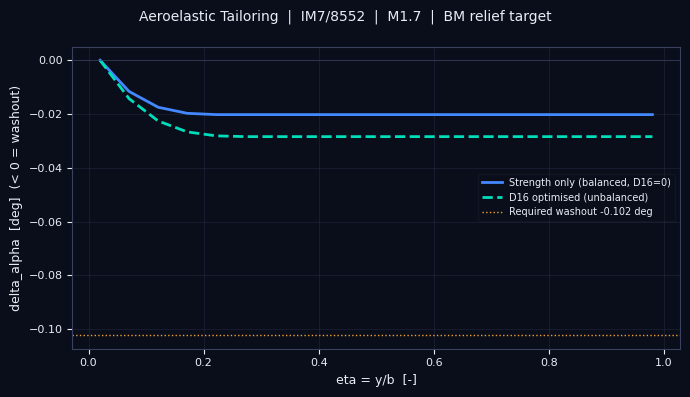

In [10]:
bg   = '#0a0e1a'; white = '#e8edf5'; dim = '#3a4060'
c1, c2 = '#4488ff', '#00ddbb'
gold = '#f0a030'

def _style(ax, legend=False):
    ax.set_facecolor(bg)
    ax.tick_params(colors=white, labelsize=8)
    ax.xaxis.label.set_color(white); ax.yaxis.label.set_color(white)
    ax.title.set_color(white)
    for sp in ax.spines.values(): sp.set_edgecolor(dim)
    ax.grid(color=dim, lw=0.4, alpha=0.5)
    if legend:
        ax.legend(fontsize=7, framealpha=0.15, labelcolor=white, facecolor=bg, edgecolor=dim)

fig, ax = plt.subplots(1, 1, figsize=(7, 4), facecolor=bg)
fig.suptitle(
    f'Aeroelastic Tailoring  |  IM7/8552  |  M{mach}  |  BM relief target',
    color=white, fontsize=10
)

ax.plot(ae1.etas, ae1.delta_alpha, color=c1, lw=2, label='Strength only (balanced, D16=0)')
ax.plot(ae3.etas, ae3.delta_alpha, color=c2, lw=2, ls='--', label='D16 optimised (unbalanced)')
ax.axhline(-relief_min_deg, color=gold, lw=1, ls=':', label=f'Required washout -{relief_min_deg:.3f} deg')
ax.axhline(0, color=dim, lw=0.5)
ax.set_xlabel('eta = y/b  [-]', fontsize=9)
ax.set_ylabel('delta_alpha  [deg]  (< 0 = washout)', fontsize=9)
_style(ax, legend=True)
plt.tight_layout()
out = os.path.join(_repo_root, "outputs", "aeroelastic_tailoring.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=bg)
print(f"Figure saved -> {out}")
plt.show()

---
## 8. Key Takeaways

1. **The washout requirement is derived from bending moment relief, not divergence speed.** The skin-panel GJ (D66 only) is far too low to compute a meaningful divergence speed — that calculation requires the full structural box. The optimizer constraint is instead driven by a 3% root BM relief target under limit load.

2. **A balanced laminate cannot generate the required washout without becoming structurally inefficient.** With D16 = 0, the only elastic twist comes from geometric sweep + bending slope. The strength-only balanced design falls short of the BM relief target.

3. **Freeing ply angles allows D16 to be engineered directly.** With angles as design variables, IPOPT finds an unbalanced laminate where bend-twist coupling generates the required washout passively — no reduction in structural stiffness is needed.

4. **The aeroelastic constraint is fully CasADi-native.** EI from A11, GJ from D66, and EK from D16 are all CasADi expressions, so IPOPT sees exact gradients through the entire constraint chain.

5. **D16 > 0 is the correct sign for a swept-back wing.** Positive D16 couples upward bending (under lift) to nose-down twist — washout. On a forward-swept wing the same coupling causes wash-in and risks divergence.

6. **Skin D66 alone cannot prevent divergence.** The structural box (closed-section torsion) is the real source of torsional stiffness. Skin-panel optimisation for aeroelastic tailoring is about controlling the coupling contribution, not the stiffness magnitude.